<!-- Cell purpose: Introduce the 800 nm embryonated egg analysis notebook. -->

# 800 nm Embryonated Egg Analysis (`analysis_800_embryonated.ipynb`)

This notebook analyzes embryonated eggs for the three 800nm treatment groups and pooled controls.

Rules applied:
- Main readout: `dt_motion_stop_h = t_motion_stop_h - t_start_h`
- Still moving at end-of-footage: `t_motion_stop_h = NA` and `death_mode = NA`
- Exclude from all analyses: `flags` contains `no_larvae`
- In-egg stop cohort: exclude `death_after_hatch`
- Max observation time: 700 h


In [3]:
# Import libraries and configure notebook settings

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test, multivariate_logrank_test
except Exception as exc:
    KaplanMeierFitter = None
    logrank_test = None
    multivariate_logrank_test = None
    print(f"lifelines import failed: {exc}. Step 7 / 8C requires `pip install lifelines`.")

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style="whitegrid", context="talk")

CSV_PATH = "master_csv/02_master_embryonated.csv"

TREATMENT_GROUP_ORDER = [
    "800-pulsed-330mW-120s",
    "800-pulsed-330mW-60s",
    "800-cw-330mW-120s",
]

CONTROL_LABELS = [
    "400-SHG-40mW-control",
    "800-control-330mW",
    "400-SHG-20mW-control",
]

GROUP_TO_LABELS = {
    "Control (pooled)": CONTROL_LABELS,
    "800-pulsed-330mW-120s": ["800-pulsed-330mW-120s"],
    "800-pulsed-330mW-60s": ["800-pulsed-330mW-60s"],
    "800-cw-330mW-120s": ["800-cw-330mW-120s"],
}

ALL_GROUP_ORDER = ["Control (pooled)", *TREATMENT_GROUP_ORDER]
DEATH_MODES = ["apoptotic_like", "necrotic_like", "uncertain"]
DEATH_MODE_DISPLAY = {
    "apoptotic_like": "Vacuolated (apoptosis-like)",
    "necrotic_like": "Lytic (necrosis-like)",
    "uncertain": "Indeterminate/hatched",
    "uncertein": "Indeterminate/hatched",
}
TERMINAL_PHENOTYPE_LABEL = "Terminal phenotype"
DEATH_MODE_DISPLAY_ORDER = [DEATH_MODE_DISPLAY[m] for m in DEATH_MODES]
DEATH_MODE_PALETTE = {
    "Vacuolated (apoptosis-like)": "#59a14f",
    "Lytic (necrosis-like)": "#e15759",
    "Indeterminate/hatched": "#4e79a7",
}
MAX_FOOTAGE_H = 700.0
ALPHA_PAIRWISE = 0.05 / 6

OUT_BASE = Path("800nm/embryonated")
PLOTS_DIR = OUT_BASE / "plots"
TABLES_DIR = OUT_BASE / "tables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
# Define helper functions for file lookup and data preparation

def resolve_csv_path(raw_path: str) -> Path:
    raw = Path(raw_path)
    stripped = Path(str(raw_path).replace("LIA-STH-Repo/", "", 1))

    start = Path.cwd().resolve()
    search_bases = [start, *start.parents]

    candidates = [raw, stripped]
    for base in search_bases:
        candidates.append(base / raw)
        candidates.append(base / stripped)

    seen = set()
    for cand in candidates:
        key = str(cand)
        if key in seen:
            continue
        seen.add(key)
        if cand.exists():
            return cand.resolve()

    raise FileNotFoundError(f"CSV not found. Tried: {[str(c) for c in candidates]}")


def to_snake_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"", "na", "none"}:
        return np.nan
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else np.nan


def normalize_flags(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    if raw == "" or raw.lower() in {"na", "none"}:
        return np.nan

    parts = [to_snake_or_nan(part) for part in raw.split(";")]
    parts = [p for p in parts if pd.notna(p)]
    if not parts:
        return np.nan
    return ";".join(parts)


def has_flag(series: pd.Series, token: str) -> pd.Series:
    token_norm = to_snake_or_nan(token)
    if pd.isna(token_norm):
        return pd.Series(False, index=series.index)
    pattern = rf"(?:^|;){re.escape(token_norm)}(?:$|;)"
    return series.fillna("").str.contains(pattern, regex=True)


def pct(n: int, d: int) -> float:
    return (100.0 * n / d) if d else np.nan


def median_iqr(series: pd.Series):
    vals = series.dropna().astype(float)
    if vals.empty:
        return np.nan, np.nan, np.nan
    return float(vals.median()), float(vals.quantile(0.25)), float(vals.quantile(0.75))


In [5]:
# Load and clean source table

csv_file = resolve_csv_path(CSV_PATH)
df = pd.read_csv(csv_file)

required_cols = [
    "egg_uid",
    "exp_label",
    "start_date",
    "control",
    "t_start_h",
    "t_motion_stop_h",
    "death_mode",
    "flags",
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

if "well_#" in df.columns:
    df = df.rename(columns={"well_#": "well_id"})

text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols:
    s = df[col].astype("string").str.strip()
    s = s.replace({"NA": pd.NA, "na": pd.NA, "": pd.NA, "None": pd.NA, "none": pd.NA}, regex=False)
    df[col] = s

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
for col in ["system", "regime", "death_mode"]:
    if col in df.columns:
        df[col] = df[col].map(to_snake_or_nan)

if "death_mode" in df.columns:
    df["death_mode"] = df["death_mode"].replace({"uncertein": "uncertain"})

if "flags" in df.columns:
    df["flags"] = df["flags"].map(normalize_flags)

df["exp_label_norm"] = df["exp_label"].map(to_snake_or_nan)

for col in [
    "control",
    "wl_nm",
    "power_mW",
    "irradiance_mW_cm2",
    "exposure_s",
    "fluence_J_cm2",
    "t_start_h",
    "t_motion_stop_h",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["dt_motion_stop_h"] = df["t_motion_stop_h"] - df["t_start_h"]

group_frames = []
for group_name, labels in GROUP_TO_LABELS.items():
    label_norm = {to_snake_or_nan(x) for x in labels}
    mask = df["exp_label_norm"].isin(label_norm)
    if group_name == "Control (pooled)":
        mask &= (df["control"] == 1)

    g = df.loc[mask].copy()
    g["analysis_group"] = group_name
    group_frames.append(g)

analysis_df = pd.concat(group_frames, ignore_index=True)
analysis_df["analysis_group"] = pd.Categorical(
    analysis_df["analysis_group"], categories=ALL_GROUP_ORDER, ordered=True
)

analysis_df["flag_no_larvae"] = has_flag(analysis_df["flags"], "no_larvae")
analysis_df["flag_death_after_hatch"] = has_flag(analysis_df["flags"], "death_after_hatch")
analysis_df["flag_exit_egg"] = has_flag(analysis_df["flags"], "exit_egg")
analysis_df["flag_terminal_twitching"] = has_flag(analysis_df["flags"], "terminal_twitching")

analysis_df["is_analyzed"] = ~analysis_df["flag_no_larvae"]
analysis_df["is_continued_motion"] = (
    analysis_df["is_analyzed"]
    & analysis_df["t_motion_stop_h"].isna()
    & analysis_df["death_mode"].isna()
)
analysis_df["is_stopped_in_egg"] = (
    analysis_df["is_analyzed"]
    & analysis_df["t_motion_stop_h"].notna()
    & (~analysis_df["flag_death_after_hatch"])
    & (analysis_df["t_motion_stop_h"] <= MAX_FOOTAGE_H)
)
analysis_df["is_event_survival"] = (
    analysis_df["is_analyzed"]
    & analysis_df["dt_motion_stop_h"].notna()
    & (analysis_df["dt_motion_stop_h"] <= MAX_FOOTAGE_H)
)
analysis_df["duration_survival_h"] = np.where(
    analysis_df["is_event_survival"], analysis_df["dt_motion_stop_h"], MAX_FOOTAGE_H
)
analysis_df["duration_survival_h"] = analysis_df["duration_survival_h"].astype(float).clip(lower=0, upper=MAX_FOOTAGE_H)

print(f"Loaded: {csv_file}")
print(f"Rows in full master table: {len(df)}")
print(f"Rows in analysis subset (4 groups): {len(analysis_df)}")

group_counts_raw = (
    analysis_df.groupby("analysis_group", observed=False)
    .size()
    .rename("n_raw")
    .reset_index()
)

group_counts_analyzed = (
    analysis_df[analysis_df["is_analyzed"]]
    .groupby("analysis_group", observed=False)
    .size()
    .rename("n_after_no_larvae_exclusion")
    .reset_index()
)

display(group_counts_raw.merge(group_counts_analyzed, on="analysis_group", how="left"))
analysis_preview_df = analysis_df[
    [
        "egg_uid",
        "analysis_group",
        "exp_label",
        "t_start_h",
        "t_motion_stop_h",
        "dt_motion_stop_h",
        "death_mode",
        "flags",
        "is_analyzed",
    ]
].copy()
analysis_preview_df[TERMINAL_PHENOTYPE_LABEL] = (
    analysis_preview_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(analysis_preview_df["death_mode"])
)
display(analysis_preview_df.drop(columns=["death_mode"]).head())


Loaded: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/master_csv/02_master_embryonated.csv
Rows in full master table: 811
Rows in analysis subset (4 groups): 176


,analysis_group,n_raw,n_after_no_larvae_exclusion
0,Control (pooled),97,97
1,800-pulsed-330mW-120s,24,24
2,800-pulsed-330mW-60s,32,31
3,800-cw-330mW-120s,23,22


,egg_uid,analysis_group,exp_label,t_start_h,t_motion_stop_h,dt_motion_stop_h,flags,is_analyzed,Terminal phenotype
0,115,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
1,116,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
2,117,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
3,118,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
4,119,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN


In [6]:
# Data QC and overview table

qc_rows = []
for group in ALL_GROUP_ORDER:
    sub = analysis_df.loc[analysis_df["analysis_group"] == group].copy()
    sub_an = sub.loc[sub["is_analyzed"]].copy()

    n_total = int(len(sub))
    n_excl_no_larvae = int(sub["flag_no_larvae"].sum())
    n_analyzed = int(len(sub_an))

    row = {
        "group": group,
        "n_total": n_total,
        "n_excluded_no_larvae": n_excl_no_larvae,
        "pct_excluded_no_larvae": round(pct(n_excl_no_larvae, n_total), 1),
        "n_analyzed": n_analyzed,
    }

    for mode in DEATH_MODES:
        n_mode = int((sub_an["death_mode"] == mode).sum())
        row[f"n_{mode}"] = n_mode
        row[f"pct_{mode}"] = round(pct(n_mode, n_analyzed), 1)

    for flag in ["death_after_hatch", "exit_egg", "terminal_twitching"]:
        n_flag = int(has_flag(sub_an["flags"], flag).sum())
        row[f"n_flag_{flag}"] = n_flag
        row[f"pct_flag_{flag}"] = round(pct(n_flag, n_analyzed), 1)

    qc_rows.append(row)

qc_overview_df = pd.DataFrame(qc_rows)
qc_overview_display_df = qc_overview_df.rename(
    columns={
        **{f"n_{mode}": f"n_{DEATH_MODE_DISPLAY.get(mode, mode)}" for mode in DEATH_MODES},
        **{f"pct_{mode}": f"pct_{DEATH_MODE_DISPLAY.get(mode, mode)}" for mode in DEATH_MODES},
    }
)
display(qc_overview_display_df)

qc_death_mode_long = []
for group in ALL_GROUP_ORDER:
    sub_an = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_analyzed = int(len(sub_an))
    for mode in DEATH_MODES:
        n_mode = int((sub_an["death_mode"] == mode).sum())
        qc_death_mode_long.append(
            {
                "group": group,
                "death_mode": mode,
                "n": n_mode,
                "pct": round(pct(n_mode, n_analyzed), 1),
            }
        )
qc_death_mode_long_df = pd.DataFrame(qc_death_mode_long)
qc_death_mode_long_df["death_mode"] = (
    qc_death_mode_long_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(qc_death_mode_long_df["death_mode"])
)
qc_death_mode_long_df = qc_death_mode_long_df.rename(columns={"death_mode": TERMINAL_PHENOTYPE_LABEL})
display(qc_death_mode_long_df)

qc_flags_long = []
for group in ALL_GROUP_ORDER:
    sub_an = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_analyzed = int(len(sub_an))
    for flag in ["death_after_hatch", "exit_egg", "terminal_twitching"]:
        n_flag = int(has_flag(sub_an["flags"], flag).sum())
        qc_flags_long.append(
            {
                "group": group,
                "flag": flag,
                "n": n_flag,
                "pct": round(pct(n_flag, n_analyzed), 1),
            }
        )
qc_flags_long_df = pd.DataFrame(qc_flags_long)
display(qc_flags_long_df)

qc_overview_display_df.to_csv(TABLES_DIR / "800_embryonated_qc_overview.csv", index=False)
qc_death_mode_long_df.to_csv(TABLES_DIR / "800_embryonated_qc_death_mode_long.csv", index=False)
qc_flags_long_df.to_csv(TABLES_DIR / "800_embryonated_qc_flags_long.csv", index=False)

print(f"Saved QC tables to: {TABLES_DIR.resolve()}")


,group,n_total,n_excluded_no_larvae,pct_excluded_no_larvae,n_analyzed,n_Vacuolated (apoptosis-like),pct_Vacuolated (apoptosis-like),n_Lytic (necrosis-like),pct_Lytic (necrosis-like),n_Indeterminate/hatched,pct_Indeterminate/hatched,n_flag_death_after_hatch,pct_flag_death_after_hatch,n_flag_exit_egg,pct_flag_exit_egg,n_flag_terminal_twitching,pct_flag_terminal_twitching
0,Control (pooled),97,0,0.0,97,0,0.0,3,3.1,12,12.4,9,9.3,1,1.0,0,0.0
1,800-pulsed-330mW-120s,24,0,0.0,24,2,8.3,17,70.8,4,16.7,4,16.7,0,0.0,0,0.0
2,800-pulsed-330mW-60s,32,1,3.1,31,0,0.0,2,6.5,4,12.9,0,0.0,0,0.0,0,0.0
3,800-cw-330mW-120s,23,1,4.3,22,0,0.0,1,4.5,0,0.0,0,0.0,0,0.0,0,0.0


,group,Terminal phenotype,n,pct
0,Control (pooled),Vacuolated (apoptosis-like),0,0.0
1,Control (pooled),Lytic (necrosis-like),3,3.1
2,Control (pooled),Indeterminate/hatched,12,12.4
3,800-pulsed-330mW-120s,Vacuolated (apoptosis-like),2,8.3
4,800-pulsed-330mW-120s,Lytic (necrosis-like),17,70.8
5,800-pulsed-330mW-120s,Indeterminate/hatched,4,16.7
6,800-pulsed-330mW-60s,Vacuolated (apoptosis-like),0,0.0
7,800-pulsed-330mW-60s,Lytic (necrosis-like),2,6.5
8,800-pulsed-330mW-60s,Indeterminate/hatched,4,12.9
9,800-cw-330mW-120s,Vacuolated (apoptosis-like),0,0.0


,group,flag,n,pct
0,Control (pooled),death_after_hatch,9,9.3
1,Control (pooled),exit_egg,1,1.0
2,Control (pooled),terminal_twitching,0,0.0
3,800-pulsed-330mW-120s,death_after_hatch,4,16.7
4,800-pulsed-330mW-120s,exit_egg,0,0.0
5,800-pulsed-330mW-120s,terminal_twitching,0,0.0
6,800-pulsed-330mW-60s,death_after_hatch,0,0.0
7,800-pulsed-330mW-60s,exit_egg,0,0.0
8,800-pulsed-330mW-60s,terminal_twitching,0,0.0
9,800-cw-330mW-120s,death_after_hatch,0,0.0


Saved QC tables to: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/embryonated/tables


In [7]:
# Motion cessation analysis (each 800nm treatment separately)

motion_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()

    n_total = int(len(sub))
    n_cont = int(sub["is_continued_motion"].sum())

    sub_stopped_in_egg = sub.loc[
        sub["is_stopped_in_egg"] & sub["dt_motion_stop_h"].notna(),
        "dt_motion_stop_h",
    ]
    n_stop_in_egg = int(len(sub_stopped_in_egg))
    med, q1, q3 = median_iqr(sub_stopped_in_egg)

    motion_rows.append(
        {
            "treatment": group,
            "n_total_excluding_no_larvae": n_total,
            "n_continued_motion": n_cont,
            "pct_continued_motion": round(pct(n_cont, n_total), 1),
            "n_stopped_in_egg": n_stop_in_egg,
            "pct_stopped_in_egg": round(pct(n_stop_in_egg, n_total), 1),
            "median_dt_motion_stop_h": round(med, 2) if pd.notna(med) else np.nan,
            "q1_dt_motion_stop_h": round(q1, 2) if pd.notna(q1) else np.nan,
            "q3_dt_motion_stop_h": round(q3, 2) if pd.notna(q3) else np.nan,
            "iqr_dt_motion_stop_h": (
                f"{q1:.2f} to {q3:.2f}" if pd.notna(q1) and pd.notna(q3) else np.nan
            ),
        }
    )

motion_summary_df = pd.DataFrame(motion_rows)
display(motion_summary_df)
motion_summary_df.to_csv(TABLES_DIR / "800_embryonated_motion_cessation_summary.csv", index=False)


,treatment,n_total_excluding_no_larvae,n_continued_motion,pct_continued_motion,n_stopped_in_egg,pct_stopped_in_egg,median_dt_motion_stop_h,q1_dt_motion_stop_h,q3_dt_motion_stop_h,iqr_dt_motion_stop_h
0,800-pulsed-330mW-120s,24,1,4.2,19,79.2,288.0,150.00,434.50,150.00 to 434.50
1,800-pulsed-330mW-60s,31,25,80.6,6,19.4,513.3,473.55,593.55,473.55 to 593.55
2,800-cw-330mW-120s,22,21,95.5,1,4.5,31.0,31.00,31.00,31.00 to 31.00


In [8]:
# Comparison table: percentage still moving at 700h

comparison_rows = []
for group in ALL_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_still = int(sub["is_continued_motion"].sum())
    comparison_rows.append(
        {
            "Treatment": group,
            "n_total": n_total,
            "n_still_moving": n_still,
            "% still moving": round(pct(n_still, n_total), 1),
        }
    )

still_moving_df = pd.DataFrame(comparison_rows)
display(still_moving_df)
still_moving_df.to_csv(TABLES_DIR / "800_embryonated_still_moving_comparison.csv", index=False)

tx_only = still_moving_df[still_moving_df["Treatment"].isin(TREATMENT_GROUP_ORDER)].copy()
most_effective = tx_only.loc[tx_only["% still moving"].idxmin()]
least_effective = tx_only.loc[tx_only["% still moving"].idxmax()]

print(
    f"Interpretation note: {most_effective['Treatment']} has the lowest still-moving fraction "
    f"({most_effective['% still moving']}%), while {least_effective['Treatment']} has the highest "
    f"({least_effective['% still moving']}%)."
)


,Treatment,n_total,n_still_moving,% still moving
0,Control (pooled),97,82,84.5
1,800-pulsed-330mW-120s,24,1,4.2
2,800-pulsed-330mW-60s,31,25,80.6
3,800-cw-330mW-120s,22,21,95.5


Interpretation note: 800-pulsed-330mW-120s has the lowest still-moving fraction (4.2%), while 800-cw-330mW-120s has the highest (95.5%).


Figure caption: Terminal phenotype composition across analyzed 800 nm embryonated treatment groups. Bars show treatment-specific percentages among analyzed eggs (no_larvae excluded), colors encode Vacuolated (apoptosis-like), Lytic (necrosis-like), and Indeterminate/hatched outcomes, and bar labels show absolute counts as n/total analyzed per treatment.


,treatment,n_total_analyzed,n,pct,Terminal phenotype
0,800-pulsed-330mW-120s,24,2,8.3,Vacuolated (apoptosis-like)
1,800-pulsed-330mW-120s,24,17,70.8,Lytic (necrosis-like)
2,800-pulsed-330mW-120s,24,4,16.7,Indeterminate/hatched
3,800-pulsed-330mW-60s,31,0,0.0,Vacuolated (apoptosis-like)
4,800-pulsed-330mW-60s,31,2,6.5,Lytic (necrosis-like)
5,800-pulsed-330mW-60s,31,4,12.9,Indeterminate/hatched
6,800-cw-330mW-120s,22,0,0.0,Vacuolated (apoptosis-like)
7,800-cw-330mW-120s,22,1,4.5,Lytic (necrosis-like)
8,800-cw-330mW-120s,22,0,0.0,Indeterminate/hatched


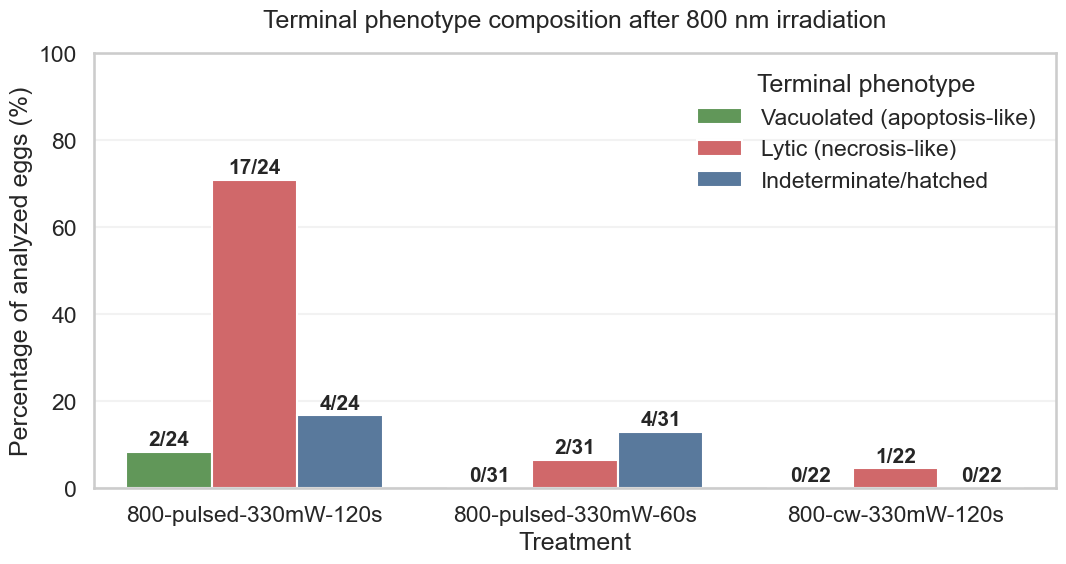

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/embryonated/plots/800_embryonated_death_mode_distribution.png


In [9]:
# Terminal phenotype distribution (n, %) per treatment

print('Figure caption: Terminal phenotype composition across analyzed 800 nm embryonated treatment groups. Bars show treatment-specific percentages among analyzed eggs (no_larvae excluded), colors encode Vacuolated (apoptosis-like), Lytic (necrosis-like), and Indeterminate/hatched outcomes, and bar labels show absolute counts as n/total analyzed per treatment.')

death_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    for mode in DEATH_MODES:
        n_mode = int((sub["death_mode"] == mode).sum())
        death_rows.append(
            {
                "treatment": group,
                "death_mode": mode,
                "n_total_analyzed": n_total,
                "n": n_mode,
                "pct": round(pct(n_mode, n_total), 1),
            }
        )

death_mode_dist_df = pd.DataFrame(death_rows)
death_mode_dist_df[TERMINAL_PHENOTYPE_LABEL] = (
    death_mode_dist_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(death_mode_dist_df["death_mode"])
)
display(death_mode_dist_df.drop(columns=["death_mode"]))

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=death_mode_dist_df,
    x="treatment",
    y="pct",
    hue=TERMINAL_PHENOTYPE_LABEL,
    hue_order=DEATH_MODE_DISPLAY_ORDER,
    order=TREATMENT_GROUP_ORDER,
    palette=DEATH_MODE_PALETTE,
    ax=ax,
)
ax.set_xlabel("Treatment")
ax.set_ylabel("Percentage of analyzed eggs (%)")
ax.set_title("Terminal phenotype composition after 800 nm irradiation", y=1.04)
ymax = death_mode_dist_df["pct"].dropna().max() if len(death_mode_dist_df) else 100
ax.set_ylim(0, max(100, (float(ymax) + 12) if pd.notna(ymax) else 100))
ax.legend(title=TERMINAL_PHENOTYPE_LABEL, frameon=False)
ax.grid(axis="y", alpha=0.25)
for container, mode_label in zip(ax.containers, DEATH_MODE_DISPLAY_ORDER):
    labels = []
    for treatment in TREATMENT_GROUP_ORDER:
        row = death_mode_dist_df[
            (death_mode_dist_df["treatment"] == treatment)
            & (death_mode_dist_df[TERMINAL_PHENOTYPE_LABEL] == mode_label)
        ]
        if row.empty:
            labels.append("")
            continue
        n_total = int(row["n_total_analyzed"].iloc[0])
        n_mode = int(row["n"].iloc[0])
        labels.append(f"{n_mode}/{n_total}" if n_total > 0 else "")
    ax.bar_label(container, labels=labels, padding=2, fontsize=15, fontweight="bold", rotation=0)
plt.tight_layout()

out_png = PLOTS_DIR / "800_embryonated_death_mode_distribution.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png.resolve()}")

death_mode_dist_df.drop(columns=["death_mode"]).to_csv(TABLES_DIR / "800_embryonated_death_mode_distribution.csv", index=False)




<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
Terminal phenotype composition across analyzed 800nm treatment groups. For each treatment, bars show the percentage of analyzed eggs (`no_larvae` excluded). Colors encode `Vacuolated (apoptosis-like)`, `Lytic (necrosis-like)`, and `Indeterminate/hatched`. Bar-top labels report absolute counts as `n / n_total_analyzed`, so percentages and denominators can be interpreted together.


In [10]:
# Death-after-hatch events per treatment

dah_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_dah = int(sub["flag_death_after_hatch"].sum())
    dah_rows.append(
        {
            "treatment": group,
            "n_total_excluding_no_larvae": n_total,
            "n_death_after_hatch": n_dah,
            "pct_death_after_hatch": round(pct(n_dah, n_total), 1),
        }
    )

death_after_hatch_df = pd.DataFrame(dah_rows)
display(death_after_hatch_df)

death_after_hatch_df.to_csv(TABLES_DIR / "800_embryonated_death_after_hatch_summary.csv", index=False)


,treatment,n_total_excluding_no_larvae,n_death_after_hatch,pct_death_after_hatch
0,800-pulsed-330mW-120s,24,4,16.7
1,800-pulsed-330mW-60s,31,0,0.0
2,800-cw-330mW-120s,22,0,0.0


Figure caption: Distribution of in-egg motion-stop timing (`dt_motion_stop_h`) for 800 nm treatments. Only eggs with observed in-egg stop events are included; groups with fewer than two observations are excluded. Boxes show median and IQR with 1.5xIQR whiskers (outlier glyphs hidden), and jittered points represent individual eggs on a 0-700 h axis.


,analysis_group,n_points
0,800-pulsed-330mW-120s,19
1,800-pulsed-330mW-60s,6
2,800-cw-330mW-120s,1


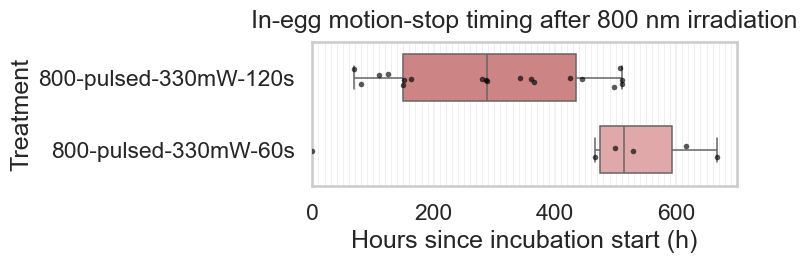

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/embryonated/plots/800_embryonated_dt_motion_stop_boxplot.png
Note: Excluded from boxplot due to insufficient in-egg stop observations (n<2): 800-cw-330mW-120s (n=1).
Note: For 800-pulsed-330mW-60s, only 6 datapoints are shown in this boxplot because 25 out of 31 eggs were still moving at the end of footage (80.6%).


In [11]:
# Horizontal boxplot + stripplot overlay: in-egg motion stop times (800nm treatments only)

print('Figure caption: Distribution of in-egg motion-stop timing (`dt_motion_stop_h`) for 800 nm treatments. Only eggs with observed in-egg stop events are included; groups with fewer than two observations are excluded. Boxes show median and IQR with 1.5xIQR whiskers (outlier glyphs hidden), and jittered points represent individual eggs on a 0-700 h axis.')

boxplot_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(TREATMENT_GROUP_ORDER)
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["egg_uid", "analysis_group", "dt_motion_stop_h", "flags", "death_mode"],
].copy()

point_counts = (
    boxplot_df.groupby("analysis_group", observed=False)
    .size()
    .reindex(TREATMENT_GROUP_ORDER, fill_value=0)
    .rename("n_points")
    .reset_index()
)
display(point_counts)

MIN_N_FOR_BOX = 2
groups_for_box = (
    point_counts.loc[point_counts["n_points"] >= MIN_N_FOR_BOX, "analysis_group"]
    .astype(str)
    .tolist()
)
excluded_groups = (
    point_counts.loc[point_counts["n_points"] < MIN_N_FOR_BOX, ["analysis_group", "n_points"]]
    .copy()
)

if not groups_for_box:
    raise ValueError(f"No treatment has at least n={MIN_N_FOR_BOX} in-egg stop points for boxplot.")

plot_df = boxplot_df[boxplot_df["analysis_group"].astype(str).isin(groups_for_box)].copy()

palette = {
    "800-pulsed-330mW-120s": "#d97878",
    "800-pulsed-330mW-60s": "#e99f9f",
    "800-cw-330mW-120s": "#e99f9f",
}

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="analysis_group",
    order=groups_for_box,
    hue="analysis_group",
    hue_order=groups_for_box,
    palette=palette,
    showfliers=False,
    width=0.65,
    dodge=False,
    linewidth=1.1,
    legend=False,
    ax=ax,
)

sns.stripplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="analysis_group",
    order=groups_for_box,
    color="black",
    size=4,
    alpha=0.65,
    jitter=0.15,
    ax=ax,
)

ax.set_xlabel("Hours since incubation start (h)")
ax.set_ylabel("Treatment")
ax.set_title("In-egg motion-stop timing after 800 nm irradiation", y=1.04)
ax.set_xlim(0, MAX_FOOTAGE_H)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
plt.tight_layout()

out_png = PLOTS_DIR / "800_embryonated_dt_motion_stop_boxplot.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

plot_df.to_csv(TABLES_DIR / "800_embryonated_dt_motion_stop_boxplot_data.csv", index=False)
point_counts.to_csv(TABLES_DIR / "800_embryonated_dt_motion_stop_boxplot_counts.csv", index=False)
print(f"Saved: {out_png.resolve()}")

if len(excluded_groups) > 0:
    excl_txt = ", ".join(
        f"{row.analysis_group} (n={int(row.n_points)})" for row in excluded_groups.itertuples(index=False)
    )
    print(
        f"Note: Excluded from boxplot due to insufficient in-egg stop observations (n<{MIN_N_FOR_BOX}): {excl_txt}."
    )


tx_name = "800-pulsed-330mW-60s"
n_presented_60s = int(point_counts.loc[point_counts["analysis_group"] == tx_name, "n_points"].sum())
tx60 = analysis_df.loc[
    (analysis_df["analysis_group"] == tx_name) & (analysis_df["is_analyzed"])
].copy()
n_total_60s = int(len(tx60))
n_still_60s = int(tx60["is_continued_motion"].sum())
pct_still_60s = round(pct(n_still_60s, n_total_60s), 1)
print(
    f"Note: For {tx_name}, only {n_presented_60s} datapoints are shown in this boxplot because "
    f"{n_still_60s} out of {n_total_60s} eggs were still moving at the end of footage "
    f"({pct_still_60s}%)."
)




<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
In-egg larval motion-stop timing for 800nm treatment groups. Each point is one egg with `is_stopped_in_egg = True` and `dt_motion_stop_h = t_motion_stop_h - t_start_h`. Eggs flagged `no_larvae`, eggs flagged `death_after_hatch`, and eggs still moving at 700 h are excluded because no in-egg stop-time event is observed. Boxplots show median and IQR with 1.5xIQR whiskers (fliers hidden); jittered points show all included eggs. Treatments with `<2` in-egg stop observations are excluded from box/IQR rendering and reported in the count table/notes.


Figure caption: Kaplan-Meier curves of continued larval motion for pooled control and 800 nm treatment groups. Event is observed motion cessation within the footage window (`event_observed=1`), censoring indicates continued motion or no in-window stop (`event_observed=0`), censor marks are shown on curves, and confidence intervals are suppressed for readability.


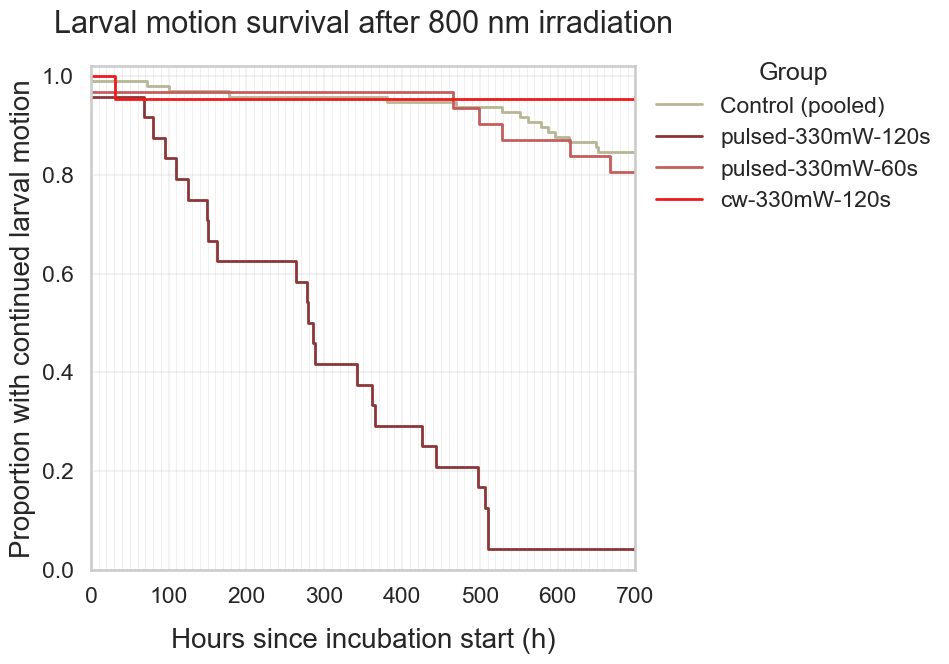

,group,n_total,n_events,n_censored,median_survival_h
0,Control (pooled),97,15,82,inf
1,800-pulsed-330mW-120s,24,23,1,279.6
2,800-pulsed-330mW-60s,31,6,25,inf
3,800-cw-330mW-120s,22,1,21,inf


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/embryonated/plots/800_embryonated_kaplan_meier_motion_survival.png


In [12]:
# Kaplan-Meier survival curve (continued larval motion)

print('Figure caption: Kaplan-Meier curves of continued larval motion for pooled control and 800 nm treatment groups. Event is observed motion cessation within the footage window (`event_observed=1`), censoring indicates continued motion or no in-window stop (`event_observed=0`), censor marks are shown on curves, and confidence intervals are suppressed for readability.')

if KaplanMeierFitter is None or logrank_test is None or multivariate_logrank_test is None:
    raise ImportError("lifelines is required for Kaplan-Meier and log-rank analyses. Install with: pip install lifelines")

survival_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(ALL_GROUP_ORDER) & analysis_df["is_analyzed"],
    [
        "egg_uid",
        "analysis_group",
        "duration_survival_h",
        "is_event_survival",
        "dt_motion_stop_h",
        "t_motion_stop_h",
        "death_mode",
        "flags",
    ],
].copy()

survival_df = survival_df.rename(
    columns={
        "duration_survival_h": "duration_h",
        "is_event_survival": "event_observed",
    }
)
survival_df["event_observed"] = survival_df["event_observed"].astype(int)
survival_df["duration_h"] = survival_df["duration_h"].fillna(MAX_FOOTAGE_H).astype(float).clip(lower=0, upper=MAX_FOOTAGE_H)

km_colors = {
    "Control (pooled)": "#b7b695",
    "800-pulsed-330mW-120s": "#8b3637",
    "800-pulsed-330mW-60s": "#c55d5d",
    "800-cw-330mW-120s": "#f11a1a",
}

fig, ax = plt.subplots(figsize=(12, 7))
km_rows = []

for group in ALL_GROUP_ORDER:
    g = survival_df.loc[survival_df["analysis_group"] == group].copy()
    if g.empty:
        continue

    kmf = KaplanMeierFitter()
    group_label = group.replace("800-", "") if group.startswith("800-") else group
    kmf.fit(
        durations=g["duration_h"],
        event_observed=g["event_observed"],
        label=group_label,
    )
    kmf.plot_survival_function(
        ax=ax,
        ci_show=False,
        color=km_colors.get(group, None),
        show_censors=True,
        censor_styles={"ms": 5, "marker": "|", "mew": 1.1},
        linewidth=2.0,
    )

    med = kmf.median_survival_time_
    km_rows.append(
        {
            "group": group,
            "n_total": int(len(g)),
            "n_events": int(g["event_observed"].sum()),
            "n_censored": int((g["event_observed"] == 0).sum()),
            "median_survival_h": float(med) if np.isfinite(med) else np.inf,
        }
    )

ax.set_xlim(0, MAX_FOOTAGE_H)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Hours since incubation start (h)", fontsize=20, labelpad=15)
ax.set_ylabel("Proportion with continued larval motion", fontsize=20)
ax.set_title("Larval motion survival after 800 nm irradiation", fontsize=22, y=1.05)
ax.grid(alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
ax.legend(title="Group", frameon=False, loc="upper left", bbox_to_anchor=(1, 1.05))
plt.tight_layout(rect=[0, 0, 0.82, 1])

out_png = PLOTS_DIR / "800_embryonated_kaplan_meier_motion_survival.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

km_summary_df = pd.DataFrame(km_rows)
display(km_summary_df)

km_summary_df.to_csv(TABLES_DIR / "800_embryonated_km_summary.csv", index=False)
survival_df.to_csv(TABLES_DIR / "800_embryonated_km_input_data.csv", index=False)
print(f"Saved: {out_png.resolve()}")




<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
Kaplan-Meier curves of continued larval motion for pooled controls and 800nm treatments over 0-700 h. The survival function is the probability of remaining motile. Event definition: observed in-window motion stop (`event_observed = 1`). Censoring definition: continued motion at footage end or no in-window stop (`event_observed = 0`), shown as tick marks. Group-wise curve comparison is evaluated with log-rank testing in Step 8C.


Figure caption: Normality diagnostics for `dt_motion_stop_h` by group (control plus 800 nm treatments). The table reports Shapiro-Wilk statistics where n>=3, and Q-Q panels compare observed quantiles to normal-theory quantiles; panels with n=1 or n=0 indicate limited or no diagnostic information and guide the downstream parametric versus non-parametric test choice.


,group,n_stopped_in_egg,shapiro_W,shapiro_p,normal_by_shapiro_p_gt_0_05,note
0,Control (pooled),6,0.729307,0.012403,False,
1,800-pulsed-330mW-120s,19,0.906484,0.063828,True,
2,800-pulsed-330mW-60s,6,0.788210,0.045917,False,
3,800-cw-330mW-120s,1,NaN,NaN,NaN,Shapiro requires n>=3


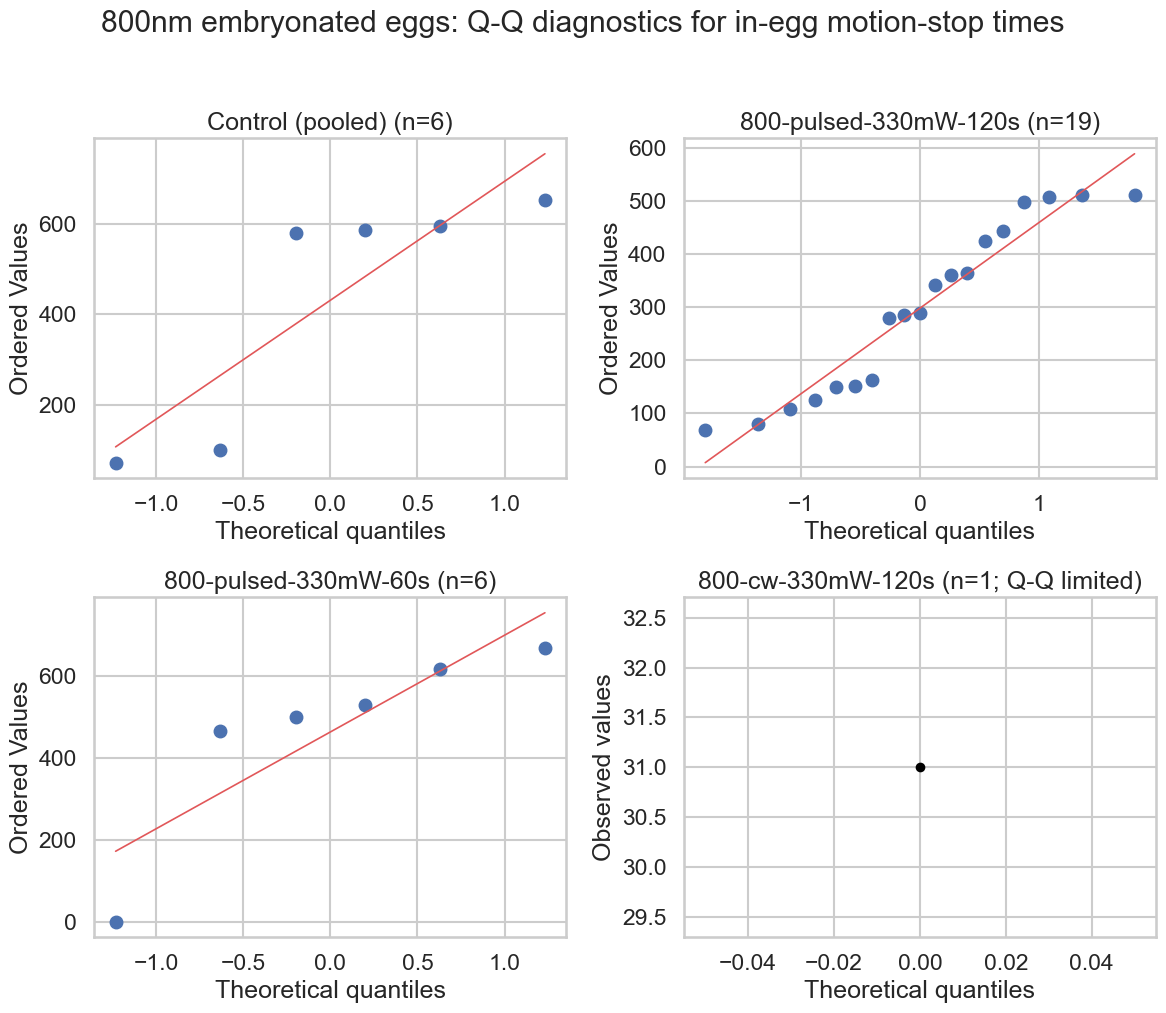

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/embryonated/plots/800_embryonated_normality_qqplots.png
Selected comparison family: non_parametric
Reason: at least one group had n<3 and/or failed Shapiro p<=0.05.


In [13]:
# Normality testing (Shapiro-Wilk) + Q-Q plots

print('Figure caption: Normality diagnostics for `dt_motion_stop_h` by group (control plus 800 nm treatments). The table reports Shapiro-Wilk statistics where n>=3, and Q-Q panels compare observed quantiles to normal-theory quantiles; panels with n=1 or n=0 indicate limited or no diagnostic information and guide the downstream parametric versus non-parametric test choice.')

time_comp_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(ALL_GROUP_ORDER)
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["analysis_group", "dt_motion_stop_h"],
].copy()

time_groups = {
    g: time_comp_df.loc[time_comp_df["analysis_group"] == g, "dt_motion_stop_h"].dropna().astype(float)
    for g in ALL_GROUP_ORDER
}

normality_rows = []
for group in ALL_GROUP_ORDER:
    vals = time_groups[group]
    n = int(len(vals))
    if n >= 3:
        sh_w, sh_p = stats.shapiro(vals)
    else:
        sh_w, sh_p = np.nan, np.nan

    normality_rows.append(
        {
            "group": group,
            "n_stopped_in_egg": n,
            "shapiro_W": float(sh_w) if pd.notna(sh_w) else np.nan,
            "shapiro_p": float(sh_p) if pd.notna(sh_p) else np.nan,
            "normal_by_shapiro_p_gt_0_05": bool(sh_p > 0.05) if pd.notna(sh_p) else np.nan,
            "note": "Shapiro requires n>=3" if n < 3 else "",
        }
    )

normality_df = pd.DataFrame(normality_rows)
display(normality_df)
normality_df.to_csv(TABLES_DIR / "800_embryonated_normality_shapiro.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, group in zip(axes.flat, ALL_GROUP_ORDER):
    vals = time_groups[group]
    n = len(vals)
    if n >= 2:
        stats.probplot(vals, dist="norm", plot=ax)
        ax.get_lines()[1].set_color("#e15759")
        ax.get_lines()[1].set_linewidth(1.2)
        ax.set_title(f"{group} (n={n})")
    elif n == 1:
        ax.scatter([0], vals.values, color="black", s=30)
        ax.set_title(f"{group} (n=1; Q-Q limited)")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Observed values")
    else:
        ax.text(0.5, 0.5, "No in-egg stop data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{group} (n=0)")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Observed values")

plt.suptitle("800nm embryonated eggs: Q-Q diagnostics for in-egg motion-stop times", y=1.02)
plt.tight_layout()
out_png = PLOTS_DIR / "800_embryonated_normality_qqplots.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")

insufficient_n_any = bool((normality_df["n_stopped_in_egg"] < 3).any())
failed_shapiro_any = bool((normality_df["shapiro_p"].dropna() <= 0.05).any())

USE_PARAMETRIC = (not insufficient_n_any) and (not failed_shapiro_any)
TEST_FAMILY = "parametric" if USE_PARAMETRIC else "non_parametric"

print("Selected comparison family:", TEST_FAMILY)
if USE_PARAMETRIC:
    print("Reason: all groups had n>=3 and Shapiro p>0.05.")
else:
    print("Reason: at least one group had n<3 and/or failed Shapiro p<=0.05.")



<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
Q-Q diagnostics for in-egg motion-stop times (`dt_motion_stop_h`) by pooled control and 800nm treatment groups. Panels compare observed quantiles to theoretical normal quantiles to assess normality assumptions used in downstream between-group testing. Titles report sample size (`n`) per group; groups with `n < 2` are marked as limited/no Q-Q diagnostics. Companion Shapiro-Wilk results above are used with these plots to choose parametric vs non-parametric test families.


In [14]:
# Group comparisons + survival curve comparisons

if KaplanMeierFitter is None or logrank_test is None or multivariate_logrank_test is None:
    raise ImportError("lifelines is required for log-rank analyses. Install with: pip install lifelines")

pairwise_order = [
    ("800-pulsed-330mW-120s", "800-pulsed-330mW-60s"),
    ("800-pulsed-330mW-120s", "800-cw-330mW-120s"),
    ("800-pulsed-330mW-60s", "800-cw-330mW-120s"),
    ("800-pulsed-330mW-120s", "Control (pooled)"),
    ("800-pulsed-330mW-60s", "Control (pooled)"),
    ("800-cw-330mW-120s", "Control (pooled)"),
]

ALPHA_REPORT = 0.005
N_PAIRWISE = len(pairwise_order)


def p_to_sig_alpha(p: float, alpha: float = ALPHA_REPORT) -> str:
    if pd.isna(p):
        return "NA"
    if p < (alpha / 100):
        return "***"
    if p < (alpha / 10):
        return "**"
    if p < alpha:
        return "*"
    return "ns"


time_stats_rows = []
vals_all = [time_groups[g].to_numpy(dtype=float) for g in ALL_GROUP_ORDER if len(time_groups[g]) > 0]

if USE_PARAMETRIC:
    overall_test_name = "One-way ANOVA"
    if len(vals_all) >= 2:
        overall_stat, overall_p = stats.f_oneway(*vals_all)
    else:
        overall_stat, overall_p = np.nan, np.nan
    pair_test_name = "Welch t-test"
else:
    overall_test_name = "Kruskal-Wallis H"
    if len(vals_all) >= 2:
        overall_stat, overall_p = stats.kruskal(*vals_all)
    else:
        overall_stat, overall_p = np.nan, np.nan
    pair_test_name = "Mann-Whitney U"

time_stats_rows.append(
    {
        "Comparison": "Overall (all groups)",
        "Statistical Test Used": overall_test_name,
        "Test Statistic": float(overall_stat) if pd.notna(overall_stat) else np.nan,
        "p_raw": float(overall_p) if pd.notna(overall_p) else np.nan,
        "p_bonf": np.nan,
        "significant_alpha_0_005": bool(overall_p <= ALPHA_REPORT) if pd.notna(overall_p) else np.nan,
        "sig": p_to_sig_alpha(float(overall_p)) if pd.notna(overall_p) else "NA",
    }
)

for a, b in pairwise_order:
    va = time_groups[a].to_numpy(dtype=float)
    vb = time_groups[b].to_numpy(dtype=float)

    if USE_PARAMETRIC:
        if len(va) >= 2 and len(vb) >= 2:
            stat_res = stats.ttest_ind(va, vb, equal_var=False, nan_policy="omit")
            stat_val = float(stat_res.statistic)
            p_raw = float(stat_res.pvalue)
        else:
            stat_val, p_raw = np.nan, np.nan
    else:
        if len(va) >= 1 and len(vb) >= 1:
            stat_res = stats.mannwhitneyu(va, vb, alternative="two-sided")
            stat_val = float(stat_res.statistic)
            p_raw = float(stat_res.pvalue)
        else:
            stat_val, p_raw = np.nan, np.nan

    p_bonf = min(p_raw * N_PAIRWISE, 1.0) if pd.notna(p_raw) else np.nan
    time_stats_rows.append(
        {
            "Comparison": f"{a} vs. {b}",
            "Statistical Test Used": pair_test_name,
            "Test Statistic": stat_val,
            "p_raw": p_raw,
            "p_bonf": p_bonf,
            "significant_alpha_0_005": bool(p_bonf <= ALPHA_REPORT) if pd.notna(p_bonf) else np.nan,
            "sig": p_to_sig_alpha(p_bonf),
        }
    )

time_stats_df = pd.DataFrame(time_stats_rows)
display(time_stats_df)
time_stats_df.to_csv(TABLES_DIR / "800_embryonated_time_statistics_summary.csv", index=False)

time_posthoc_sig_df = time_stats_df.loc[
    (time_stats_df["Comparison"] != "Overall (all groups)")
    & (time_stats_df["significant_alpha_0_005"] == True)
].copy()

rows = []
for _, r in time_posthoc_sig_df.iterrows():
    g1_name, g2_name = r["Comparison"].split(" vs. ")

    g1 = time_groups[g1_name].to_numpy(dtype=float)
    g2 = time_groups[g2_name].to_numpy(dtype=float)
    if len(g1) == 0 or len(g2) == 0:
        continue

    mean_g1 = float(np.mean(g1))
    mean_g2 = float(np.mean(g2))
    med_g1 = float(np.median(g1))
    med_g2 = float(np.median(g2))
    sd_g1 = float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan
    sd_g2 = float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan

    rows.append(
        {
            "comparison": r["Comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": med_g1,
            "median_group2_h": med_g2,
            "median_diff_h_(g2-g1)": med_g2 - med_g1,
            "mean_group1_h": mean_g1,
            "mean_group2_h": mean_g2,
            "mean_diff_h_(g2-g1)": mean_g2 - mean_g1,
            "sd_group1_h": sd_g1,
            "sd_group2_h": sd_g2,
            "sd_diff_indep_h": np.sqrt(sd_g1 ** 2 + sd_g2 ** 2) if np.isfinite(sd_g1) and np.isfinite(sd_g2) else np.nan,
            "p_bonf": r["p_bonf"],
            "sig": r["sig"],
        }
    )

if rows:
    time_sig_diffs_df = pd.DataFrame(rows).sort_values(["comparison"]).reset_index(drop=True)
else:
    time_sig_diffs_df = pd.DataFrame(
        columns=[
            "comparison",
            "n_group1",
            "n_group2",
            "median_group1_h",
            "median_group2_h",
            "median_diff_h_(g2-g1)",
            "mean_group1_h",
            "mean_group2_h",
            "mean_diff_h_(g2-g1)",
            "sd_group1_h",
            "sd_group2_h",
            "sd_diff_indep_h",
            "p_bonf",
            "sig",
        ]
    )
display(time_sig_diffs_df)
time_sig_diffs_df.to_csv(TABLES_DIR / "800_embryonated_time_significant_differences.csv", index=False)


if "survival_df" not in globals():
    raise RuntimeError("Run Step 7 first to create survival_df before Step 8C.")

overall_lr = multivariate_logrank_test(
    event_durations=survival_df["duration_h"],
    groups=survival_df["analysis_group"],
    event_observed=survival_df["event_observed"],
)

survival_stats_rows = [
    {
        "Comparison": "Overall (all curves)",
        "Log-rank chi2": float(overall_lr.test_statistic),
        "p_raw": float(overall_lr.p_value),
        "p_bonf": np.nan,
        "significant_alpha_0_005": bool(overall_lr.p_value <= ALPHA_REPORT),
        "sig": p_to_sig_alpha(float(overall_lr.p_value)),
        "n_group1": np.nan,
        "n_group2": np.nan,
        "n_events_group1": np.nan,
        "n_events_group2": np.nan,
    }
]

for a, b in pairwise_order:
    ga = survival_df.loc[survival_df["analysis_group"] == a]
    gb = survival_df.loc[survival_df["analysis_group"] == b]

    if len(ga) > 0 and len(gb) > 0:
        lr = logrank_test(
            ga["duration_h"],
            gb["duration_h"],
            event_observed_A=ga["event_observed"],
            event_observed_B=gb["event_observed"],
        )
        chi2 = float(lr.test_statistic)
        p_raw = float(lr.p_value)
    else:
        chi2 = np.nan
        p_raw = np.nan

    p_bonf = min(p_raw * N_PAIRWISE, 1.0) if pd.notna(p_raw) else np.nan
    survival_stats_rows.append(
        {
            "Comparison": f"{a} vs. {b}",
            "Log-rank chi2": chi2,
            "p_raw": p_raw,
            "p_bonf": p_bonf,
            "significant_alpha_0_005": bool(p_bonf <= ALPHA_REPORT) if pd.notna(p_bonf) else np.nan,
            "sig": p_to_sig_alpha(p_bonf),
            "n_group1": int(len(ga)),
            "n_group2": int(len(gb)),
            "n_events_group1": int(ga["event_observed"].sum()) if len(ga) > 0 else np.nan,
            "n_events_group2": int(gb["event_observed"].sum()) if len(gb) > 0 else np.nan,
        }
    )

survival_stats_df = pd.DataFrame(survival_stats_rows)
display(survival_stats_df)
survival_stats_df.to_csv(TABLES_DIR / "800_embryonated_survival_logrank_summary.csv", index=False)

survival_posthoc_sig_df = survival_stats_df.loc[
    (survival_stats_df["Comparison"] != "Overall (all curves)")
    & (survival_stats_df["significant_alpha_0_005"] == True)
].copy()
display(survival_posthoc_sig_df)
survival_posthoc_sig_df.to_csv(TABLES_DIR / "800_embryonated_survival_logrank_significant_pairs.csv", index=False)

print(
    "Significance coding used in this cell (alpha=0.005): "
    "* for p<0.005, ** for p<0.0005, *** for p<0.00005 (based on Bonferroni-adjusted p for pairwise tests)."
)

method_meta_df = pd.DataFrame(
    [
        {
            "selected_test_family": TEST_FAMILY,
            "pairwise_alpha_report": ALPHA_REPORT,
            "pairwise_n_comparisons": N_PAIRWISE,
            "normality_decision_rule": "parametric only if all groups n>=3 and Shapiro p>0.05",
        }
    ]
)
method_meta_df.to_csv(TABLES_DIR / "800_embryonated_stats_method_metadata.csv", index=False)




,Comparison,Statistical Test Used,Test Statistic,p_raw,p_bonf,significant_alpha_0_005,sig
0,Overall (all groups),Kruskal-Wallis H,6.741866,0.080597,NaN,False,ns
1,800-pulsed-330mW-120s vs. 800-pulsed-330mW-60s,Mann-Whitney U,26.000000,0.052253,0.313519,False,ns
2,800-pulsed-330mW-120s vs. 800-cw-330mW-120s,Mann-Whitney U,19.000000,0.118433,0.710598,False,ns
3,800-pulsed-330mW-60s vs. 800-cw-330mW-120s,Mann-Whitney U,5.000000,0.571429,1.000000,False,ns
4,800-pulsed-330mW-120s vs. Control (pooled),Mann-Whitney U,35.000000,0.171226,1.000000,False,ns
5,800-pulsed-330mW-60s vs. Control (pooled),Mann-Whitney U,17.000000,0.937229,1.000000,False,ns
6,800-cw-330mW-120s vs. Control (pooled),Mann-Whitney U,0.000000,0.285714,1.000000,False,ns


,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,sd_diff_indep_h,p_bonf,sig


,Comparison,Log-rank chi2,p_raw,p_bonf,significant_alpha_0_005,sig,n_group1,n_group2,n_events_group1,n_events_group2
0,Overall (all curves),159.929801,1.897930e-34,NaN,True,***,NaN,NaN,NaN,NaN
1,800-pulsed-330mW-120s vs. 800-pulsed-330mW-60s,48.691082,2.996258e-12,1.797755e-11,True,***,24.0,31.0,23.0,6.0
2,800-pulsed-330mW-120s vs. 800-cw-330mW-120s,39.402950,3.447757e-10,2.068654e-09,True,***,24.0,22.0,23.0,1.0
3,800-pulsed-330mW-60s vs. 800-cw-330mW-120s,2.298014,1.295395e-01,7.772373e-01,False,ns,31.0,22.0,6.0,1.0
4,800-pulsed-330mW-120s vs. Control (pooled),119.743838,7.198057e-28,4.318834e-27,True,***,24.0,97.0,23.0,15.0
5,800-pulsed-330mW-60s vs. Control (pooled),0.250437,6.167676e-01,1.000000e+00,False,ns,31.0,97.0,6.0,15.0
6,800-cw-330mW-120s vs. Control (pooled),1.685007,1.942604e-01,1.000000e+00,False,ns,22.0,97.0,1.0,15.0


,Comparison,Log-rank chi2,p_raw,p_bonf,significant_alpha_0_005,sig,n_group1,n_group2,n_events_group1,n_events_group2
1,800-pulsed-330mW-120s vs. 800-pulsed-330mW-60s,48.691082,2.996258e-12,1.797755e-11,True,***,24.0,31.0,23.0,6.0
2,800-pulsed-330mW-120s vs. 800-cw-330mW-120s,39.402950,3.447757e-10,2.068654e-09,True,***,24.0,22.0,23.0,1.0
4,800-pulsed-330mW-120s vs. Control (pooled),119.743838,7.198057e-28,4.318834e-27,True,***,24.0,97.0,23.0,15.0


Significance coding used in this cell (alpha=0.005): * for p<0.005, ** for p<0.0005, *** for p<0.00005 (based on Bonferroni-adjusted p for pairwise tests).
